# Testing Libraries

In [ ]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import importlib
import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))
sys.path.append(os.path.abspath('/home/rinbha/orchestra-sdk-2.1-1.python/'))

sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/sigpy-custom")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
%matplotlib widget
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


## io

### Radial

In [7]:
# add paths
from bpt_motus.io import RadialArchive

In [8]:
import bpt_motus.io.radial_reader as rr
importlib.reload(rr)

from bpt_motus.io.radial_reader import RadialArchive

In [9]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute"

# Create the object
radial = RadialArchive(inpdir)

radial.get_ksp(force_reload=False)

INFO: Loading cached raw radial data from /mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute...


In [10]:
print(f"xk shape: {radial.xk_time.shape}")
print(f"coords shape: {radial.coords_time.shape}")
print(f"dcf shape: {radial.dcf_time.shape}")
print(f"time_ordering shape: {radial.time_ordering.shape}")

xk shape: (22, 39950, 1633)
coords shape: (39950, 1633, 3)
dcf shape: (39950, 1633)
time_ordering shape: (39950,)


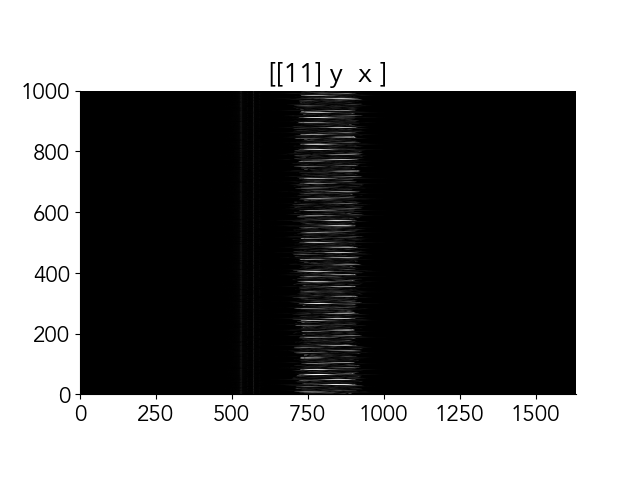

In [11]:
xk_f = sp.ifft(radial.xk_time[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

In [12]:
del radial

### Bravo

In [25]:
from bpt_motus.io import BravoArchive

In [26]:
import bpt_motus.io.bravo_reader as br
importlib.reload(br)

from bpt_motus.io.bravo_reader import BravoArchive

In [27]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo"

# Create the object
bravo = BravoArchive(inpdir)

bravo.get_ksp(force_reload=False)

INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo/raw_data/data_dict.pkl


In [28]:
for key in bravo.data_dict.keys():
    print(f"{key} shape: {bravo.data_dict[key].shape}")

xk_time shape: (22, 58520, 384)
xk_recon shape: (22, 384, 308, 190)
coords shape: (58520, 384, 3)


In [29]:
im_recon = sp.ifft(bravo.data_dict['xk_recon'], axes=(-1,-2,-3))

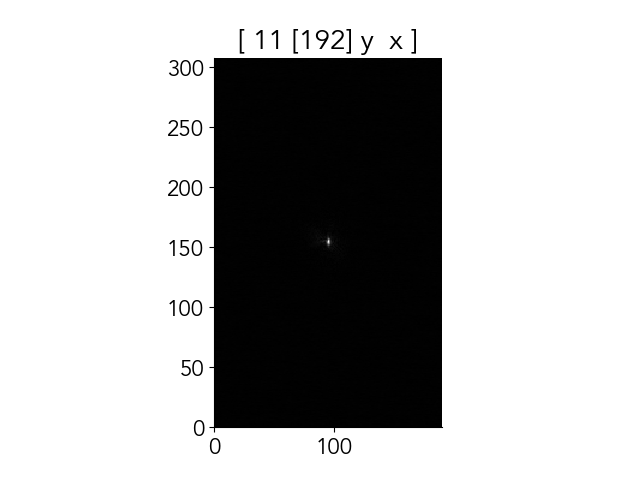

In [30]:
pl.ImagePlot(bravo.data_dict['xk_recon'])

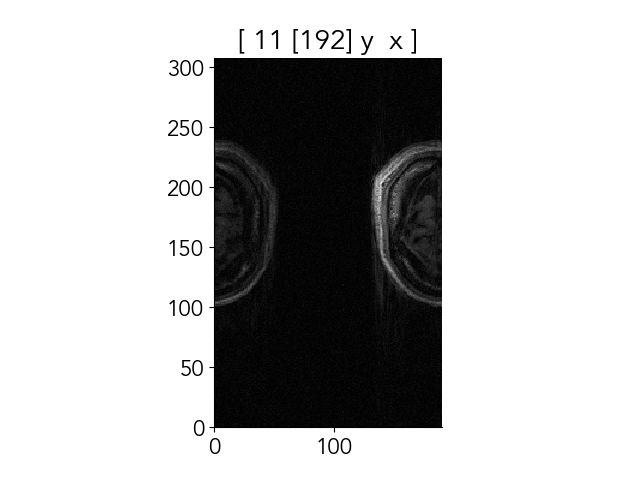

In [32]:
pl.ImagePlot(im_recon)

In [33]:
del bravo, im_recon

### Organize Radial Acquisitions into Phases

In [13]:
from bpt_motus.io import SplitRadialAcq

In [19]:
import bpt_motus.io.acq_splitter as acs
importlib.reload(acs)

from bpt_motus.io.acq_splitter import SplitRadialAcq

In [20]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/"

# Create the object
split_exp = SplitRadialAcq(inp_dir=inpdir, verbose=True, calib_source="hires", no_motion_range=(0,15000), calib_range=(20000,35000), inf_range=(35000, None))

In [21]:
split_exp.run()

INFO: Generating no motion dataset.
INFO: Generating calibration dataset.
INFO: Generating inference dataset.


## preprocessing

### Split k-space and BPT

In [23]:
from bpt_motus.preprocessing import SplitXkBPT

In [24]:
import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)

from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [60]:
# Split no motion data
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"
split_xk_bpt_nm = SplitXkBPT(inp_dir=nomotion_inpdir, verbose=True)
split_xk_bpt_nm.run()
# Split calibration data
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
split_xk_bpt_c = SplitXkBPT(inp_dir=calib_inpdir, verbose=True)
split_xk_bpt_c.run()
# Split inference data
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
split_xk_bpt_inf = SplitXkBPT(inp_dir=inf_inpdir, verbose=True)
split_xk_bpt_inf.run()

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


In [61]:
print(f"Cleaned k-space shape: {split_xk_bpt_nm.xk_cleaned.shape}")
print(f"BPT/PTs shape: {split_xk_bpt_nm.bpts.shape}")

Cleaned k-space shape: (6, 15000, 1633)


AttributeError: 'SplitXkBPT' object has no attribute 'bpts'

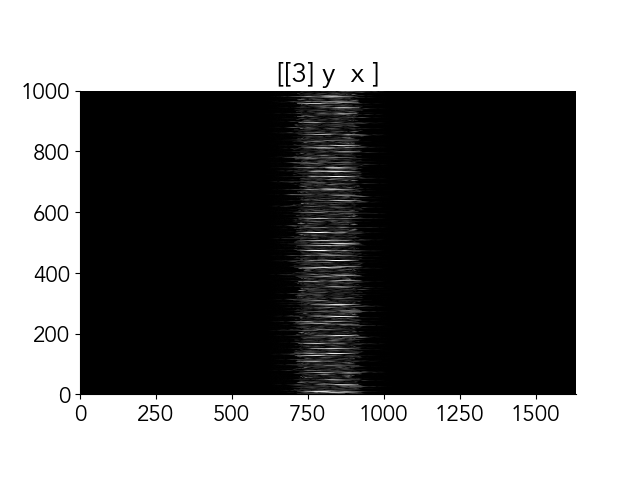

In [37]:
xk_f = sp.ifft(split_xk_bpt_c.xk_cleaned[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

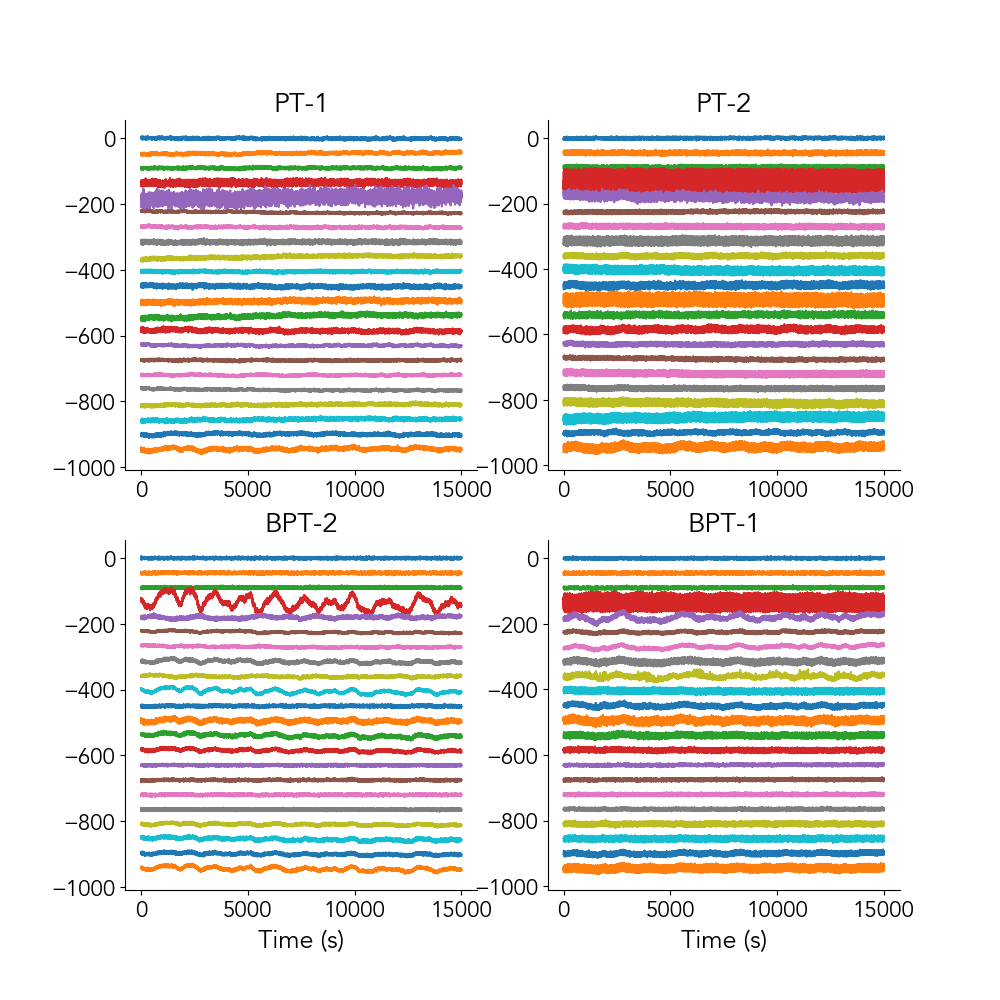

In [40]:
def plot_bpt(bpt, tr=1, window=1, shift=0, figsize=(10,10), titles = ["PT-1", "PT-2", "BPT-2", "BPT-1"]):
    nbpts, npe, ncoils = bpt.shape
    
    plt.figure(figsize=figsize)
    t = np.arange(npe)*tr
    # Plot
    for i in range(nbpts):
        plt.subplot(nbpts//2, 2, i+1)
        plt.plot(t, bpt[i] - np.mean(bpt[i],axis=0) + np.arange(ncoils)*shift);
        plt.title(titles[i])
        if i > 1:
            plt.xlabel("Time (s)")

plot_bpt(split_xk_bpt_c.bpts, shift = -45)

### Process BPT/PTs

In [ ]:
from bpt_motus.preprocessing import ProcessBPT

In [ ]:
import bpt_motus.preprocessing.process_bpt as pbpt
importlib.reload(pbpt)

from bpt_motus.preprocessing.process_bpt import ProcessBPT

In [ ]:
# Process calibration BPT
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
proc_bpt_c = ProcessBPT(inp_dir=calib_inpdir, verbose=True, phase="calib")
proc_bpt_c.run()
# Process inference BPT
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
proc_bpt_i = ProcessBPT(inp_dir=inf_inpdir, verbose=True, phase="inf")
proc_bpt_i.run()

In [ ]:
no_motion_reference.run(force_reload=True)

INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, dcf, and coords from radial data.
INFO: Cropping spokes by 3.
INFO: Preparing adjoint NUFFT operator and inputs.
INFO: Getting cartesian k-space of reference.
INFO: Getting coil sensitivity maps of reference.
INFO: Getting reference image.


Done.


SenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]

### Process xk

#### No Motion Reference

In [ ]:
from bpt_motus.preprocessing import NoMotionReference

In [10]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import NoMotionReference

In [11]:
# Path to radial ScanArchive folder
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"

# Create the object
no_motion_reference = NoMotionReference(inp_dir=nomotion_inpdir, verbose=True)

In [12]:
no_motion_reference.run(force_reload=True)

INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, dcf, and coords from radial data.
INFO: Cropping spokes by 3.
INFO: Preparing adjoint NUFFT operator and inputs.
INFO: Getting cartesian k-space of reference.
INFO: Getting coil sensitivity maps of reference.
INFO: Getting reference image.


Done.


SenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
a = 1
for i in tqdm(range(20)):
    a += 1

In [ ]:
S_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/S_nomotion_hires.npy")
csm_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/csm_hires.npy")

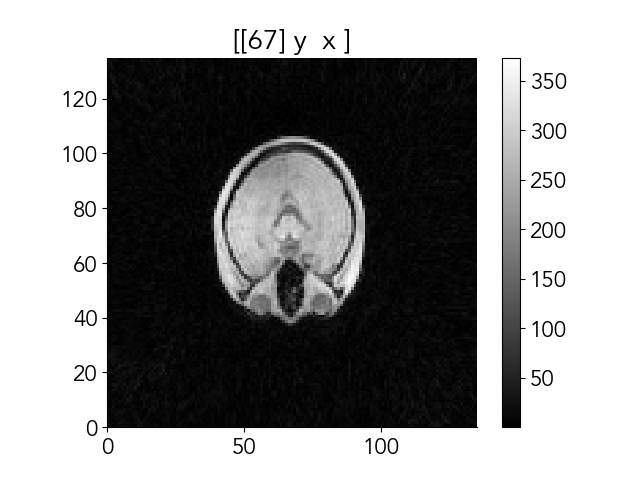

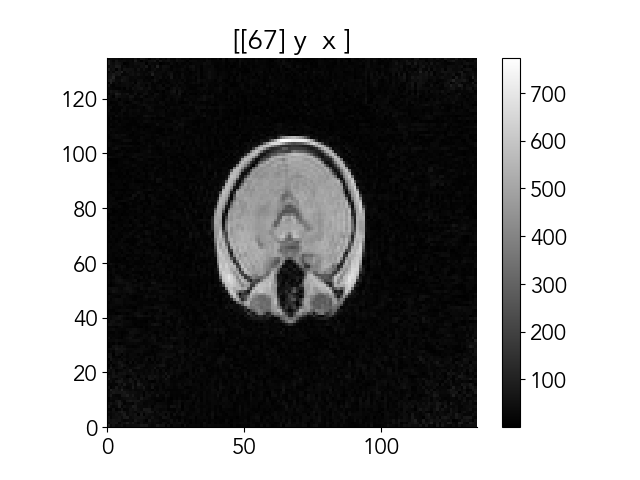

In [ ]:
pl.ImagePlot(S_old, colormap='gray')
pl.ImagePlot(no_motion_reference.S, colormap='gray')

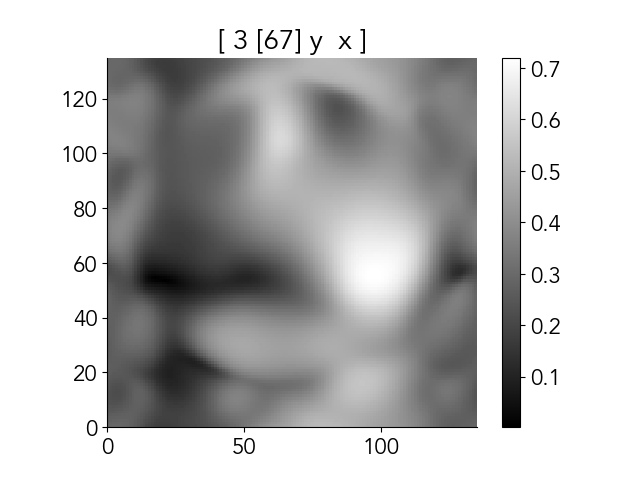

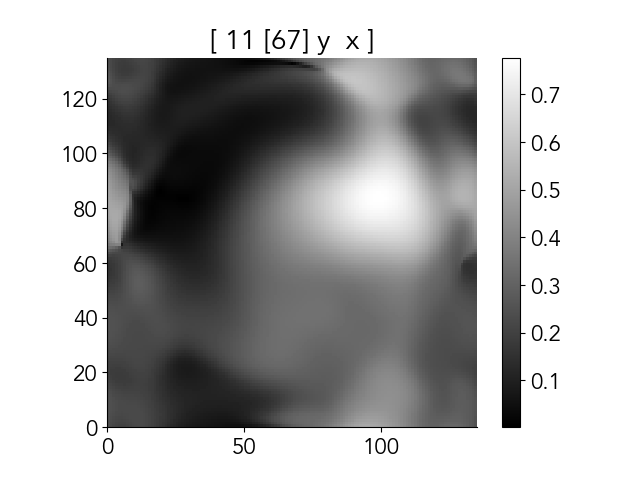

In [58]:
pl.ImagePlot(csm_old, colormap='gray')
pl.ImagePlot(no_motion_reference.csm, colormap='gray')

#### Motion Frames

In [164]:
from bpt_motus.preprocessing import MotionFrames

In [168]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import MotionFrames

In [169]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/radial/"

# Create the object
motion_frames = MotionFrames(inp_dir=inpdir, verbose=True)

In [170]:
motion_frames.run(force_reload=True)

INFO: Radial acquisition split into frames not found. Extracting with crop factor 8...
INFO: Getting xk, dcf, and coords from radial data.
INFO: Cropping spokes by 8.
INFO: Splitting radial data into frames.


In [171]:
motion_frames.xk_frames.shape, motion_frames.coords_frames.shape, motion_frames.dcf_frames.shape

((6, 195, 500, 205), (195, 500, 205, 3), (195, 500, 205))

In [172]:
motion_frames.frames_center_spokes

array([  250,   350,   450,   550,   650,   750,   850,   950,  1050,
        1150,  1250,  1350,  1450,  1550,  1650,  1750,  1850,  1950,
        2050,  2150,  2250,  2350,  2450,  2550,  2650,  2750,  2850,
        2950,  3050,  3150,  3250,  3350,  3450,  3550,  3650,  3750,
        3850,  3950,  4050,  4150,  4250,  4350,  4450,  4550,  4650,
        4750,  4850,  4950,  5050,  5150,  5250,  5350,  5450,  5550,
        5650,  5750,  5850,  5950,  6050,  6150,  6250,  6350,  6450,
        6550,  6650,  6750,  6850,  6950,  7050,  7150,  7250,  7350,
        7450,  7550,  7650,  7750,  7850,  7950,  8050,  8150,  8250,
        8350,  8450,  8550,  8650,  8750,  8850,  8950,  9050,  9150,
        9250,  9350,  9450,  9550,  9650,  9750,  9850,  9950, 10050,
       10150, 10250, 10350, 10450, 10550, 10650, 10750, 10850, 10950,
       11050, 11150, 11250, 11350, 11450, 11550, 11650, 11750, 11850,
       11950, 12050, 12150, 12250, 12350, 12450, 12550, 12650, 12750,
       12850, 12950,